## Creating a PD Scorecard

Today you will cover most of the tools needed to make a basic PD Scorecard, similar to how they are created in banks for use by the credit departments.

We will also use data from banks instead of S&P's data for exposition.  This will hopefully give you a better understanding of how banks work as well as the expectations that banks have.

***


In [5]:
%run '/Users/ghost/Desktop/Credit/code/data_for_modeling_v0.py'


There are 43 factors in the variable list_of_factors.

There are 37,339 rows in financials.
There are 3,734 unique companies.
there are 677 defaults in the data.

   4,638    Energy
   4,672    Materials
   7,412    Industrials
   7,768    Consumer Discretionary
   3,250    Consumer Staples
   3,337    Health Care
   3,319    Information Technology
   2,943    Communication Services



In [10]:
list_of_factors

['roa',
 'roe',
 'operating_margin',
 'net_profit_margin',
 'ceq_to_assets',
 'debt_to_equity',
 'debt_to_capital',
 'liabilities_to_assets',
 'debt_to_assets',
 'liab_to_tang_assets',
 'debt_to_tang_assets',
 'interest_coverage',
 'dscr',
 'fcrr',
 'current_ratio',
 'quick_ratio',
 'quick_ratio_alt',
 'cash_ratio',
 'intan_to_assets',
 'goodwill_to_assets',
 'accruals',
 'accruals_alt',
 'inventory_turnover',
 'receivables_turnover',
 'asset_turnover',
 'ocf_to_debt',
 'free_cash_flow',
 'fcf_to_debt',
 'dividend_yield',
 'dividend_payout',
 'sg&a_intensity',
 'rd_intensity',
 'capex_ratio',
 'sales_growth',
 'earnings_growth',
 'ocf_growth',
 'asset_growth',
 'dividend_growth',
 'book_value_per_share',
 'price_to_book',
 'eps',
 'price_to_earnings',
 'total_assets',
 'leverage_x_coverage']

### Definition of a Model
The name <font color = 'lightgreen'><u>scorecard</u></font> is both historical and unfortunate.  A scorecard is a tool that provides a score, most often used in credit underwriting and monitoring.  While they were originally designed using only expert input, they have more recently become full statistical models.  Despite this transformation, the scorecard label remains, causing many market participants to underestimate both their power as well as the significant investment in time and personnel to create.

In 2011, the Federal Reserve, the OCC, and the FDIC jointly issued guidance for managing model risk (<a href="https://www.federalreserve.gov/supervisionreg/srletters/sr1107.htm">SR 11-7</a>).  In this guidance, they define a model as:

>For the purposes of this document, the term model refers to a quantitative method, system, or approach that applies statistical, economic, financial, or mathematical theories, techniques, and assumptions to process input data into quantitative estimates. A model consists of three components: an <font color="lightgreen">information input</font> component, which delivers assumptions and data to the model; a <font color="lightgreen">processing component</font>, which transforms inputs into estimates; and a <font color="lightgreen">reporting component</font>, which translates the estimates into useful <font color="lightgreen">business information</font>.

In practice, the definition has evolved to include any calculations that can enter into any business decision, from the largest, most complex systems to just a few cells of code in Excel.

### Step 1 - Define the purpose
<u><b><font size = 5>Is the model PIT or TTC?</b></u><br></font>
The answer for a general scorecard is virtually always Through-the-Cycle (TTC) instead of Point-in-Time (PIT).  We explore PIT models later in the semester.

The U.S. Final Rules for Basel II guides banks on how to manage credit risks and provides maybe the best desciption of TTC ratings. <br>
> "PD for a wholesale exposure to a non-defaulted obligor is the bank’s empirically based best estimate of the long-run average one-year default rate for the rating grade assigned by the bank to the obligor, capturing the average default experience for obligors in the rating grade over a mix of economic conditions (including economic downturn conditions) sufficient to provide a reasonable estimate of the average one-year default rate over the economic cycle for the rating grade."

Japan calls for a five-year forecast horizon while still requiring PDs to be annualized.  Europe is closer to the U.S. but has subtle differences.

The main considerations for a TTC model are:
- Having enough historical data to cover at least one full economic cycle.
- Choosing more stable variables to include in the model.  For example, if you want to include earnings, don't use just the last quarter's earnings, take a multi-year average instead.



<u><b><font size = 5>What is the forecast horizon?</font></b></u><br>
<font color = 'lightgreen'>The typical forecast horizon in the U.S. is one year, though this generally refers to how PDs are normalized, not the actual horizon.</font>

One "twist" to this is that we want the models to be developed as they will be used.
- Financial statement dates usually refer to the date that financial data is frozen, not when the financial statements are released and ratings are updated.
- Financial statements are usually released six to eight weeks after the statement date and ratings may not be updated for another two-to-three months.

One other subtlety to pay attention to is that bank's usually know or at least suspect that their customers are in distress about six months prior to an actual default.  Including data from this period in the model will cause the model to be more of a signal that a customer is <font color = 'lightgreen'> already in distress</font> and less of a model forecasting future issues.

<i><font color = 'lightgreen'> Many banks use a shifted one-year measurement period, starting six months after the statement date and going to eighteen months.</font></i>

<u><b><font size = 5>What types of default will be included?</font></b></u><br>
<a href="https://www.bis.org/publ/bcbsca.htm">Basel II</a> provides guidelines for what a bank should consider a default.

A default is considered to have occurred with regard to a particular obligor when either or both of the two following events have taken place.

- The bank considers that the obligor is unlikely to pay its credit obligations to the banking group in full, without recourse by the bank to actions such as realizing security (if held).
- The obligor is past due more than 90 days on any material credit obligation to the banking group. Overdrafts will be considered as being past due once the customer has breached an advised limit or been advised of a limit smaller than current outstandings.

The elements to be taken as indications of unlikeliness to pay include:

- The bank puts the credit obligation on non-accrued status.
- The bank makes a charge-off or account-specific provision resulting from a significant perceived decline in credit quality subsequent to the bank taking on the exposure.
- The bank sells the credit obligation at a material credit-related economic loss.
- The bank consents to a distressed restructuring of the credit obligation where this is likely to result in a diminished financial obligation caused by the material forgiveness, or postponement, of principal, interest or (where relevant) fees.
- The bank has filed for the obligor’s bankruptcy or a similar order in respect of the obligor’s credit obligation to the banking group.
- The obligor has sought or has been placed in bankruptcy or similar protection where this would avoid or delay repayment of the credit obligation to the banking group.

The item referring to "a distressed restructuring" is also called a distressed debt exchange.  Fitch Ratings has published an article with more information <a href="https://www.fitchratings.com/research/corporate-finance/unsuccessful-distressed-debt-exchanges-may-lead-to-bankruptcy-28-09-2020">here</a>.  They provided an example as follows:
>For example, in February 2020, California Resources Corporation (CRC), an oil and natural gas producer operating in California, commenced a private offer to exchange its outstanding notes due in 2022, notes due in 2021, and notes due in 2024. The 2022 notes would be exchanged for either 50 cents on the dollar in new notes and 52.941 Class B shares, or 70 cents on the dollar in new term loans and 9.799 warrants. The 2021 notes could be exchanged for 47.5 cents on the dollar of new notes and 50.294 Class B shares, or 65 cents on the dollar in new term loans and 9.099 warrants. The 2024 notes could be exchanged for 35 cents on the dollar in new notes and 37.058 Class B shares, or 50 cents on the dollar in new term loans and 6.999 warrants.



<u><b><font size = 5>What types of data can be included?</font></b></u>
- Financial statement data - most common for commerical customers
- Qualitative indicators (e.g. managment quality or quality of repayment methods)
- Transaction data from deposit and checkings accounts
- Other publicly available data

### Step 2 - Aquire and Clean the Data

<font color = 'lightgreen'>We will be using the data we put together in Module 2.0.</font>

The data provided in this class will already be somewhat clean so you won't have to much to it.  Some things to think about are:
- Does internal data exist?  Will vendor-based data solutions be needed?
- How do you treat missing data?
- How do you treat outliers?
- Quarterly data is different than annual data.  How do you deal with that?

For the last bullet, some fields in financial statements are cumulative through the fiscal year, resetting to zero at the end of the year.  <font color = 'lightgreen'>We will use only annual data from the fiscal year end reports.</font>

### Step 3 - Ratio Generation

<font color = 'lightgreen'>We've already done this in Module 2.0,</font> but there are always new ways to create new factors.

There are a couple of important things to deal with in this step.  

<u> Avoiding too many size variables</u><br>
Customer sizes often vary significantly and every entry in their financial statements scale with them.  For example, we are comfortable using total assets or total revenues as size but, without normalization, even things like accounts receivable will act as size variables.
- Normal corporates, most fields are usually divided by total assets.
- Dividing by revenues should be avoided because they are sometimes highly variable.
- For banking, many credit related variables can be divided by total loans, while other balance sheet items can be divided by total assets.  Total loans themselves can be divided by total assets.

<u> Introducing non-linearities</u><br>
OLS and logistic regressions both assume all factors are linear.  
- It is well known that leverage is most important for smaller, high-PD customers.  Larger, low-PD customers are more sensitive to debt coverage ratios.  It is possible to have a variable that shifts from one to the other depending on customer size.
- Similarly, smaller customers are more sensitive to cash flow and cash-on-hand while larger customers are sensitive to external financing sources.
- Factor-by-factor, you can plot the factor against average default rates and you might see a non-linear path.  Using the empirically derived average PD instead of the factor will lead to more significant results.

In [11]:
# The following ratio is an interesting ratio that sometimes captures the weakening of leverage
# when coverage because relatively more powerful

financials['leverage_x_coverage'] = financials.debt_to_assets * financials.interest_coverage
list_of_factors.append('leverage_x_coverage')

In [12]:
# Functions for plotting default behavior for different factors

from plotly.subplots import make_subplots

def bucket_by_equal_defaults(
    df: pd.DataFrame,
    factor: str,
    default_col: str = "default_flag",
    n_buckets: int = 10,
) -> pd.DataFrame:
    """
    Create buckets so each bucket has ~the same number of defaults.
    Buckets are defined by factor cutpoints derived from default observations.
    Returns a copy with columns: bucket, bucket_low, bucket_high.
    """
    d = df[[factor, default_col]].copy()
    d = d.dropna(subset=[factor, default_col])

    # Sort by factor
    d = d.sort_values(factor).reset_index(drop=True)

    # Pull defaults only and compute cutpoints based on their factor distribution
    dflt = d[d[default_col] == 1].copy()
    n_defaults = len(dflt)
    if n_defaults == 0:
        raise ValueError("No defaults found; can't make equal-default buckets.")
    if n_buckets > n_defaults:
        # You *can* still do it, but many buckets would be empty of defaults.
        # Clamp to something meaningful.
        n_buckets = n_defaults

    # Boundaries from defaults: quantiles of factor among defaults
    # These become bin edges for the full population.
    probs = np.linspace(0, 1, n_buckets + 1)
    edges = np.quantile(dflt[factor].to_numpy(), probs)

    # Make edges strictly increasing (ties happen with discrete factors)
    # If ties collapse bins, we'll reduce bucket count after the fact.
    edges = np.unique(edges)

    if len(edges) < 3:
        raise ValueError(
            "Factor has too many ties among defaults; not enough distinct edges to form buckets."
        )

    # Assign bins to ALL observations using those edges.
    # Include -inf/+inf so everyone gets assigned.
    full_edges = np.concatenate(([-np.inf], edges[1:-1], [np.inf]))

    d["bucket"] = pd.cut(d[factor], bins=full_edges, labels=False, include_lowest=True)

    # Create human-friendly bin bounds for hover
    # (use finite versions for display)
    bin_lows = full_edges[:-1].copy()
    bin_highs = full_edges[1:].copy()

    # Map per-row bounds
    d["bucket_low"] = d["bucket"].map(lambda b: bin_lows[int(b)])
    d["bucket_high"] = d["bucket"].map(lambda b: bin_highs[int(b)])

    return d


def plot_bucket_calibration_plotly(
    df: pd.DataFrame,
    factor: str,
    default_col: str = "default_flag",
    n_buckets: int = 10,
):
    b = bucket_by_equal_defaults(df, factor=factor, default_col=default_col, n_buckets=n_buckets)

    agg = (
        b.groupby("bucket", as_index=False)
         .agg(
             n=("bucket", "size"),
             n_defaults=(default_col, "sum"),
             default_rate=(default_col, "mean"),
             bucket_low=("bucket_low", "first"),
             bucket_high=("bucket_high", "first"),
             factor_median=(factor, "median"),
         )
         .sort_values("bucket")
         .reset_index(drop=True)
    )

    # Odds / log-odds with safe handling for 0 or 1 default rates
    eps = 1e-12
    p = np.clip(agg["default_rate"].to_numpy(), eps, 1 - eps)
    agg["odds"] = p / (1 - p)
    agg["log_odds"] = np.log(agg["odds"])

    # Hover text
    hover = [
        f"Bucket: {row.bucket}<br>"
        f"Range: ({row.bucket_low:.4g}, {row.bucket_high:.4g}]<br>"
        f"{factor} median: {row.factor_median:.4g}<br>"
        f"N: {int(row.n)}<br>"
        f"Defaults: {int(row.n_defaults)}<br>"
        f"Default rate: {row.default_rate:.4g}<br>"
        f"Odds: {row.odds:.4g}<br>"
        f"Log-odds: {row.log_odds:.4g}"
        for row in agg.itertuples(index=False)
    ]

    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=("Default rate", "Odds", "Log-odds", ""),
        horizontal_spacing=0.12,
        vertical_spacing=0.18,
    )

    x = agg["factor_median"]
    
    fig.add_trace(
        go.Scatter(
            x=x,
            y=agg["default_rate"],
            mode="lines+markers",
            text=hover,
            hoverinfo="text"
        ),
        row=1, col=1
    )
    
    fig.add_trace(
        go.Scatter(
            x=x,
            y=agg["odds"],
            mode="lines+markers",
            text=hover,
            hoverinfo="text"
        ),
        row=1, col=2
    )
    
    fig.add_trace(
        go.Scatter(
            x=x,
            y=agg["log_odds"],
            mode="lines+markers",
            text=hover,
            hoverinfo="text"
        ),
        row=2, col=1
    )
    
    fig.update_xaxes(title_text=f"{factor} (bucket median)", row=1, col=1)
    fig.update_xaxes(title_text=f"{factor} (bucket median)", row=1, col=2)
    fig.update_xaxes(title_text=f"{factor} (bucket median)", row=2, col=1)

    fig.update_yaxes(title_text="Default rate", row=1, col=1)
    fig.update_yaxes(title_text="Odds", row=1, col=2)
    fig.update_yaxes(title_text="Log-odds", row=2, col=1)

    fig.update_layout(
        height=700,
        width=950,
        showlegend=False,
        title=f'Bucketed calibration for "{factor}" (buckets balanced by defaults)',
        plot_bgcolor="white",
    )
    fig.update_xaxes(showgrid=True, gridcolor="LightGray")
    fig.update_yaxes(showgrid=True, gridcolor="LightGray")

    fig.show()

    return agg  # handy to inspect / export



In [13]:
list_of_factors

['roa',
 'roe',
 'operating_margin',
 'net_profit_margin',
 'ceq_to_assets',
 'debt_to_equity',
 'debt_to_capital',
 'liabilities_to_assets',
 'debt_to_assets',
 'liab_to_tang_assets',
 'debt_to_tang_assets',
 'interest_coverage',
 'dscr',
 'fcrr',
 'current_ratio',
 'quick_ratio',
 'quick_ratio_alt',
 'cash_ratio',
 'intan_to_assets',
 'goodwill_to_assets',
 'accruals',
 'accruals_alt',
 'inventory_turnover',
 'receivables_turnover',
 'asset_turnover',
 'ocf_to_debt',
 'free_cash_flow',
 'fcf_to_debt',
 'dividend_yield',
 'dividend_payout',
 'sg&a_intensity',
 'rd_intensity',
 'capex_ratio',
 'sales_growth',
 'earnings_growth',
 'ocf_growth',
 'asset_growth',
 'dividend_growth',
 'book_value_per_share',
 'price_to_book',
 'eps',
 'price_to_earnings',
 'total_assets',
 'leverage_x_coverage',
 'leverage_x_coverage']

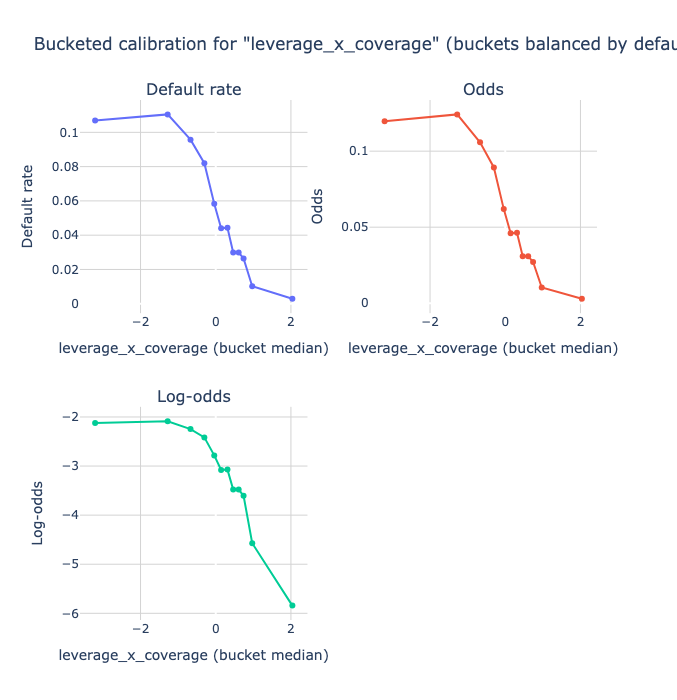

In [14]:
factor = "leverage_x_coverage"
agg = plot_bucket_calibration_plotly(financials, factor=factor, default_col="default_flag", n_buckets=12)

### Step 4 - Choose a Perfomance Measure
This topic will be addressed more fully in the next lecture.  For now, know that we typically use a cascading decision process.
- Relative ordering measures such as the area under the ROC curve (AUC), accuracy ratio (AR), or average default position (ADP) are used to ensure the core models are powerful.
- To assign the model outputs to specific ratings (or specific PDs), we use a mix of methods, including checking historical PDs and adjusting to ensure ratings are not too concentrated in any single bucket.

<i><font color = 'lightgreen'>The AUC, AR, and ADP are all mathematically equivalent.  Which you choose is up to personal preference.</font></i>
- Statisticians and consumer risk managers typically prefer the AUC.
- The financial industry and wholesale risk managers generally prefer the AR.
- Moody's Ratings uses the ADP and most market participants are not yet aware this exists.
    - I've recently been informed that Moody's Analytics still uses the AUC.


### Step 5 - Single Factor Analysis
If we had infinite computing power, we could skip this step.  We normally start with between 100 and 250 potential factors, covering thousands to hundreds of thousands of obligors over ten to twenty years.  Running every possible combination of factors would take days.  Instead, we trim the factors by testing each on its own, usually using the performance measure from Step 4 but sometimes also using standard correlations.

There is a certain amount of subjectivity about where to make the cutoff but that decision rarely matters.

In [15]:
from sklearn.metrics import roc_auc_score

aucs = []
for _ in list_of_factors:
    a = financials[~financials[_].isna()]
    a = a[(a[_] != np.inf) & (a[_] != -np.inf)]
    aucs.append([_, roc_auc_score(a.default_flag, a[_])])

aucs = sorted(aucs, key=lambda x: x[1])
for _ in aucs:
    print(f'{_[1]:2.3f} \t {_[0]}')

0.131 	 interest_coverage
0.131 	 fcrr
0.132 	 roa
0.139 	 eps
0.151 	 net_profit_margin
0.170 	 dscr
0.174 	 leverage_x_coverage
0.174 	 leverage_x_coverage
0.176 	 ocf_to_debt
0.216 	 price_to_book
0.218 	 fcf_to_debt
0.223 	 ceq_to_assets
0.227 	 price_to_earnings
0.227 	 free_cash_flow
0.230 	 book_value_per_share
0.233 	 operating_margin
0.266 	 dividend_payout
0.270 	 accruals_alt
0.285 	 total_assets
0.305 	 dividend_growth
0.310 	 dividend_yield
0.318 	 accruals
0.339 	 asset_growth
0.355 	 ocf_growth
0.388 	 roe
0.396 	 rd_intensity
0.418 	 cash_ratio
0.418 	 quick_ratio_alt
0.420 	 goodwill_to_assets
0.429 	 quick_ratio
0.439 	 current_ratio
0.444 	 sales_growth
0.459 	 intan_to_assets
0.467 	 asset_turnover
0.489 	 earnings_growth
0.493 	 sg&a_intensity
0.498 	 receivables_turnover
0.527 	 debt_to_equity
0.534 	 capex_ratio
0.547 	 inventory_turnover
0.627 	 liab_to_tang_assets
0.684 	 debt_to_tang_assets
0.772 	 liabilities_to_assets
0.794 	 debt_to_capital
0.801 	 debt_to_

For the AUC score, 50% is effectively random, with no information.  We are looking for scores closer to 0 or 1.  

### Step 6 - Multi Factor Analysis
This is where we take the remaining factors and run all potential combination of factors.  We typically try every two to six factor combination, using other techniques to determine how many factors is ultimately most correct.

Note that:

- I would normally use a weighted regression, which is relatively 

In [16]:
from itertools import combinations

factors = [x[0] for x in aucs if abs(x[1] - 0.5) > 0.2]
factor_combs = list(combinations(factors, 3))

print(f'\nWith {len(factors)} factors, there are {len(factor_combs):,} possible combinations.\n')


With 22 factors, there are 1,540 possible combinations.



In [17]:
19 * 20 * 21 / 1 / 2 / 3

1330.0

In [18]:
# Trying just one model at a time.

import statsmodels.api as sm

#factors_for_model = ['debt_to_assets', 'interest_coverage', 'fcrr']
factors_for_model = list(factor_combs[500])

a = financials.copy()
for _ in factors_for_model:
    a = a[~a[_].isna()]
    a = a[(a[_] != np.inf) & (a[_] != -np.inf)]


y = a.default_flag
x = a[factors_for_model]
x = sm.add_constant(x)

model = sm.Logit(y, x).fit()
print(model.summary())

predictions = model.predict(x)
print(f'\nThe AUC for this model is {roc_auc_score(a.default_flag, predictions):2.3f}.\n')

Optimization terminated successfully.
         Current function value: 0.078244
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:           default_flag   No. Observations:                33285
Model:                          Logit   Df Residuals:                    33281
Method:                           MLE   Df Model:                            3
Date:                Mon, 02 Mar 2026   Pseudo R-squ.:                 0.05536
Time:                        20:13:03   Log-Likelihood:                -2604.4
converged:                       True   LL-Null:                       -2757.0
Covariance Type:            nonrobust   LLR p-value:                 7.292e-66
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -4.1182      0.045    -91.718      0.000      -4.206      -4.030
roa              -3.

In [19]:
y_np = y.to_numpy()
n1 = (y_np == 1).sum()
n0 = (y_np == 0).sum()
w1 = n0 / n1
sample_weight = np.where(y_np == 1, w1, 1.0)

model = sm.GLM(
    y_np, x,
    family=sm.families.Binomial(),
    var_weights=sample_weight
).fit()

y_prob = model.predict(x)

auc_w = roc_auc_score(y, y_prob)
print('\nstatsmodels weighted')
print(f'\nROC AUC: {auc_w:.4f}\n')

print(model.summary())


statsmodels weighted

ROC AUC: 0.8742

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                33285
Model:                            GLM   Df Residuals:                    33281
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -33435.
Date:                Mon, 02 Mar 2026   Deviance:                       66870.
Time:                        20:13:03   Pearson chi2:                 3.31e+16
No. Iterations:                     8   Pseudo R-squ. (CS):             0.5126
Covariance Type:            nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const 

### Steps 7 & 8 - Documentation and Validation
<u> Documentation</u><br>
After choosing a final model, it usually takes a three person team about a month to wrap up all the required documentation.  This documentation is used by the validation group and by regulators.  Further, all materials required for historical assessment should be kept.  This includes:
- Data used in development
- Code used in development
- Proof of communication with and approval by modelers managers, model owners, and model users
- Any additional documentation that was generated during the development process

<u> Validation</u><br>
All banks are required to have large model validation teams.  Most large, non-bank financial institutions now do the same for best practices.  The validation process is time consuming for both the validators and the model development team, often taking 3 to 6 months.

Again, from SR 11-7:
>Validation involves a degree of independence from model development and use. Generally, validation is done by staff who are not responsible for model development or use and do not have a stake in whether a model is determined to be valid. 

Validators are expected to test:
- inputs
- processing
- outputs
- reports

They are also expected to implement tests of the following:
- Evaluation of Conceptual Soundness
- Outcomes Analysis
- Ongoing Monitoring

Columbia's ERM program has a model risk class taught by Dr. Peter Russo, focused on everything involved in model validation.  
___

## Effective Sample Size

We know that the amount of information in our data isn't well represented by the number of records we have:

- Company financials don't change much over time.
- Even a defaulting company will have similar financials for rows not indicating default and rows indicating default.

At the extreme, if financials for companies never changed, the amount of unique information used for regressions would only be the number of companies.  *** We need a method to estimate how many real observations we have. ***

This is a concept widely used outside of credit.  The main idea is to look at the variance of the predicted variable (y in a X --> y regression).  



Let groups be $\large g = 1,\dots,G$. Group g has $\large n_g$ observations $\large y_{ig}$. Define the group mean

$$\large \bar y_g = \frac{1}{n_g}\sum_{i=1}^{n_g} y_{ig}$$

the total sample size

$$\large N=\sum_{g=1}^G n_g$$

and the overall mean

$$\large \bar y = \frac{1}{N}\sum_{g=1}^G\sum_{i=1}^{n_g} y_{ig}$$

Total sum of squares:
$$\large \mathrm{TSS}=\sum_{g=1}^G\sum_{i=1}^{n_g}(y_{ig}-\bar y)^2$$

Within-group sum of squares:
$$\large \mathrm{WSS}=\sum_{g=1}^G\sum_{i=1}^{n_g}(y_{ig}-\bar y_g)^2$$

Between-group sum of squares:
$$\large \mathrm{BSS}=\sum_{g=1}^G n_g(\bar y_g-\bar y)^2$$

Variance decomposition identity:
$$\large \mathrm{TSS}=\mathrm{WSS}+\mathrm{BSS}$$

If BSS is large relative to TSS, it means that $y$ doesn't change much inside each group, reducing the effective number of observations.  

___

This doesn't work well with credit because y is nothing but a bunch of ones and zeros.  Instead, we can use the predicted $PD$ from a model.  This makes the measure model dependent but still valid.

What do you think could make the ESS change from model-to-model?

In [20]:
def estimate_ess_from_predictions(
    df: pd.DataFrame,
    group_col: str = "gvkey",
    pred_col: str = "prediction",
    pred_is_pd: bool = True,
    clip_pd: float = 1e-6,
    use_equal_cluster_size: bool = False,
) -> dict:
    """
    Estimate an effective sample size (ESS) from grouped model outputs.

    Core idea (population-style law of total variance):
        Var(z) = E[Var(z | group)] + Var(E[z | group])

    where z is a continuous score. For PD models, use z = logit(PD) by default.

    Then define an ICC-like ratio on z:
        rho = Var(E[z|group]) / Var(z)

    and a Kish-style ESS (exchangeable within-group dependence approximation):
        ESS = N / (1 + (n_bar - 1) * rho)

    Notes:
    - This is a heuristic scalar ESS. It is most interpretable when within-group
      dependence is roughly exchangeable (similar correlation within each gvkey).
    - If cluster sizes vary a lot, set use_equal_cluster_size=False (default) to
      use the harmonic-mean-like adjustment via mean cluster size in the Kish term.
      This is still an approximation; see returned diagnostics.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain group_col and pred_col.
    group_col : str
        Group identifier, e.g. gvkey.
    pred_col : str
        Model output column.
    pred_is_pd : bool
        If True, treat pred_col as PD in (0,1) and convert to logit scale.
        If False, treat pred_col as already a continuous score (e.g. logits).
    clip_pd : float
        PDs are clipped to [clip_pd, 1-clip_pd] before logit.
    use_equal_cluster_size : bool
        If True, use n_bar = N/G. If False, uses mean cluster size anyway,
        but also returns size dispersion diagnostics to judge approximation quality.

    Returns
    -------
    dict with keys:
        - N, G
        - n_bar, n_min, n_med, n_max, cv_n
        - var_total, var_within, var_between
        - rho_between_share
        - design_effect
        - ess
    """
    if group_col not in df.columns or pred_col not in df.columns:
        raise KeyError(f"df must contain columns {group_col!r} and {pred_col!r}")

    x = df[[group_col, pred_col]].dropna()
    if x.empty:
        raise ValueError("No non-missing rows after dropping NA.")

    # Build score z
    p = x[pred_col].astype(float).to_numpy()
    if pred_is_pd:
        p = np.clip(p, clip_pd, 1.0 - clip_pd)
        z = np.log(p / (1.0 - p))  # logit
    else:
        z = p  # already a score/logit

    x = x.assign(_z=z)

    # Basic counts
    n_i = x.groupby(group_col)["_z"].size()
    N = int(n_i.sum())
    G = int(n_i.shape[0])

    if N < 2 or G < 1:
        raise ValueError("Need at least 2 rows and at least 1 group.")

    n_bar = float(N / G) if use_equal_cluster_size else float(n_i.mean())
    n_min, n_med, n_max = int(n_i.min()), float(n_i.median()), int(n_i.max())
    cv_n = float(n_i.std(ddof=0) / n_i.mean()) if n_i.mean() > 0 else np.nan

    # Total variance of z (population style)
    z_all = x["_z"].to_numpy()
    mu = float(z_all.mean())
    var_total = float(((z_all - mu) ** 2).mean())

    # Within variance: sum_i (n_i/N) * Var_i(z) with population denom n_i
    # Compute per-group population variance
    grp_stats = x.groupby(group_col)["_z"].agg(["mean", "var", "count"])
    # pandas var defaults to sample variance (ddof=1); convert to population variance
    # pop_var = sample_var * (n-1)/n  for n>1; for n=1, pop_var = 0
    n = grp_stats["count"].to_numpy(dtype=float)
    s2 = grp_stats["var"].fillna(0.0).to_numpy(dtype=float)  # sample var; NaN for n=1
    pop_var = np.where(n > 1, s2 * (n - 1.0) / n, 0.0)

    weights = n / N
    var_within = float(np.sum(weights * pop_var))

    # Between variance: sum_i (n_i/N) * (mu_i - mu)^2
    mu_i = grp_stats["mean"].to_numpy(dtype=float)
    var_between = float(np.sum(weights * (mu_i - mu) ** 2))

    # Sanity: var_total should equal within + between (numerical tolerance)
    # We'll trust float rounding, but you can check if desired.

    # "rho" share of variance attributable to between-groups on z scale
    rho = 0.0 if var_total <= 0 else float(var_between / var_total)

    # Kish-style design effect and ESS using average cluster size
    design_effect = 1.0 + (n_bar - 1.0) * rho
    ess = float(N / design_effect) if design_effect > 0 else np.nan

    return {
        "N": N,
        "G": G,
        "n_bar": n_bar,
        "n_min": n_min,
        "n_med": n_med,
        "n_max": n_max,
        "cv_n": cv_n,
        "var_total": var_total,
        "var_within": var_within,
        "var_between": var_between,
        "rho_between_share": rho,
        "design_effect": design_effect,
        "ess": ess,
        "group": group_col,
    }

In [21]:
a['prediction'] = predictions

out = estimate_ess_from_predictions(a, group_col="gvkey", pred_col="prediction", pred_is_pd=True)

print(f'\nThe effective sample size (ESS) is {out['ess']:,.2f} out of {out['N']:,} total observations.')
print(f'There are {out['G']:,} total {out['group']} groups.')
print(f'Between Group correlation is {100*out['rho_between_share']:.2f}%.')
print(f'CV_n is {out['cv_n']:.2f}.\n')



The effective sample size (ESS) is 7,470.33 out of 33,285 total observations.
There are 3,247 total gvkey groups.
Between Group correlation is 37.35%.
CV_n is 0.92.



___
CV_n is the "coefficient of variation" of group sizes.  

$$ \text{cv}_n \;=\; \frac{\mathrm{Std}(n_i)}{\mathbb{E}[n_i]} $$

The ESS calculations that I'm using are only perfectly correct if all group sizes are the same.  Anything less than about 0.5 is consistent with the original method derivations.  Above 0.5 but less than 1.0 is still useful but maybe a little less certain.  Above 1.0, the ESS calculations may not be as useful.

It is possible to adjust for group size heterogeneity, which I'll do for you in the next class.